# BÀI TẬP THỰC HÀNH: CÁC GIẢI THUẬT PHÂN LOẠI


| Bài | Dữ liệu | Thuật toán yêu cầu | File cần có |
|---|---|---|---|
| 2.1.3 | Titanic | Decision Tree, Random Forest | `train.csv` |
| 2.1.4 | Bệnh tiểu đường | Decision Tree, Random Forest | `diabetes.csv` |
| 2.2.3 | Bệnh tiểu đường | SVM | `diabetes.csv` |
| 2.2.4 | Animal condition | SVM | `animal` |
| 2.3.3 | Customer behaviour | Naive Bayes | `Customer_Behaviour.csv` |
| 2.3.4 | Mushroom | Naive Bayes | `mushrooms.csv` |

**Quy trình chung (CRISP-DM rút gọn):** khám phá dữ liệu → tiền xử lý (giá trị thiếu, mã hóa biến phân loại, chuẩn hóa) →
chia train/test (có `stratify`) → huấn luyện + `GridSearchCV` (5-fold) → đánh giá (accuracy, precision, recall, F1, ROC AUC,
confusion matrix) → phân tích quá khớp & đặc trưng quan trọng.

> Mọi bước tiền xử lý nằm trong `Pipeline` nên chỉ được `fit` trên tập train → tránh rò rỉ dữ liệu.

## 0. Thư viện và hàm dùng chung

In [16]:
import warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import RandomForestClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import (ConfusionMatrixDisplay, accuracy_score,
                             classification_report, f1_score, precision_score,
                             recall_score, roc_auc_score)
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.naive_bayes import BernoulliNB, GaussianNB
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier

%matplotlib inline
warnings.filterwarnings("ignore")
OUT_DIR = Path("ket_qua/4_ThucHanh")
OUT_DIR.mkdir(exist_ok=True)

### 0.1 Hàm khám phá dữ liệu nhanh

In [17]:
def kham_pha(df, target):
    print("Kích thước:", df.shape)
    display(df.head())
    print("\nKiểu dữ liệu & giá trị thiếu:")
    display(pd.DataFrame({"dtype": df.dtypes.astype(str),
                          "thiếu": df.isna().sum(),
                          "số giá trị khác nhau": df.nunique()}))
    print("\nPhân bố nhãn:")
    display(df[target].value_counts())
    df[target].value_counts().plot.bar(rot=0)
    plt.title(f"Phân bố nhãn '{target}'")
    plt.show()
    num = df.select_dtypes(include="number")
    if num.shape[1] > 1:
        display(num.describe().round(2))

### 0.2 Hàm huấn luyện – tối ưu – đánh giá

In [18]:
MODEL_NAMES = {"dt": "Decision Tree", "rf": "Random Forest", "svm": "SVM", "nb": "Naive Bayes"}

def build_preprocessor(X):
    num_cols = X.select_dtypes(include="number").columns.tolist()
    cat_cols = [c for c in X.columns if c not in num_cols]
    try:
        ohe = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
    except TypeError:                         # scikit-learn cũ (< 1.2)
        ohe = OneHotEncoder(handle_unknown="ignore", sparse=False)
    pre = ColumnTransformer([
        ("num", Pipeline([("imp", SimpleImputer(strategy="median")),
                          ("sc", StandardScaler())]), num_cols),
        ("cat", Pipeline([("imp", SimpleImputer(strategy="most_frequent")),
                          ("oh", ohe)]), cat_cols),
    ], sparse_threshold=0)
    return pre, num_cols, cat_cols


def get_models(only_categorical):
    nb_est = BernoulliNB() if only_categorical else GaussianNB()
    nb_grid = ({"clf__alpha": [0.1, 0.5, 1.0]} if only_categorical
               else {"clf__var_smoothing": [1e-9, 1e-8, 1e-6, 1e-4]})
    return {
        "dt": (DecisionTreeClassifier(random_state=42),
               {"clf__max_depth": [2, 3, 4, 5, 6, 8, 10, None],
                "clf__min_samples_leaf": [1, 5, 10],
                "clf__criterion": ["gini", "entropy"]}),
        "rf": (RandomForestClassifier(random_state=42, n_jobs=-1),
               {"clf__n_estimators": [50, 100, 200],
                "clf__max_depth": [3, 5, 8, None],
                "clf__min_samples_leaf": [1, 3, 5]}),
        "svm": (SVC(probability=True, random_state=42),
                {"clf__kernel": ["linear", "rbf", "poly"],
                 "clf__C": [0.1, 1, 10, 100],
                 "clf__gamma": ["scale", 0.01, 0.1]}),
        "nb": (nb_est, nb_grid),
    }


def chay_bai_tap(df, target, models, ten_bai, zero_as_nan=(), drop=()):
    """Tiền xử lý -> GridSearchCV -> đánh giá cho các mô hình trong `models`."""
    df = df.copy()
    for c in zero_as_nan:                    
        df[c] = df[c].replace(0, np.nan)
    df = df.drop(columns=[c for c in drop if c in df.columns])
    df = df.dropna(subset=[target])

    le = LabelEncoder()
    y = le.fit_transform(df[target])
    X = df.drop(columns=[target])
    classes = [str(c) for c in le.classes_]
    binary = len(classes) == 2

    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y)
    pre, num_cols, cat_cols = build_preprocessor(X)
    print(f"Lớp: {classes} | Train: {len(X_train)} | Test: {len(X_test)}")
    print(f"Đặc trưng số ({len(num_cols)}): {num_cols}")
    print(f"Đặc trưng phân loại ({len(cat_cols)}): {cat_cols}")

    results, best = [], {}
    for key in models:
        est, grid = get_models(only_categorical=(len(num_cols) == 0))[key]
        name = MODEL_NAMES[key]
        print(f"\n==================== {name} ====================")
        pipe = Pipeline([("pre", pre), ("clf", est)])
        gs = GridSearchCV(pipe, grid, cv=5, n_jobs=-1,
                          scoring="roc_auc" if binary else "f1_macro")
        gs.fit(X_train, y_train)
        model = gs.best_estimator_
        best[key] = model
        y_pred = model.predict(X_test)
        avg = "binary" if binary else "macro"
        row = {"Mô hình": name,
               "Tham số tốt nhất": {k.replace("clf__", ""): v for k, v in gs.best_params_.items()},
               "CV score": round(gs.best_score_, 4),
               "Train acc": round(accuracy_score(y_train, model.predict(X_train)), 4),
               "Test acc": round(accuracy_score(y_test, y_pred), 4),
               "Precision": round(precision_score(y_test, y_pred, average=avg), 4),
               "Recall": round(recall_score(y_test, y_pred, average=avg), 4),
               "F1": round(f1_score(y_test, y_pred, average=avg), 4)}
        if binary:
            row["ROC AUC"] = round(roc_auc_score(y_test, model.predict_proba(X_test)[:, 1]), 4)
        results.append(row)
        print("Tham số tốt nhất:", row["Tham số tốt nhất"])
        print(classification_report(y_test, y_pred, target_names=classes))
        ConfusionMatrixDisplay.from_predictions(y_test, y_pred, display_labels=classes, cmap="Blues")
        plt.title(f"{ten_bai} - {name}")
        plt.savefig(OUT_DIR / f"{ten_bai}_{key}_confusion.png", bbox_inches="tight")
        plt.show()

    res = pd.DataFrame(results)
    res.to_csv(OUT_DIR / f"{ten_bai}_so_sanh.csv", index=False)
    print("\n================ BẢNG SO SÁNH ================")
    display(res.drop(columns=["Tham số tốt nhất"]))
    print("Train acc >> Test acc nghĩa là mô hình có dấu hiệu quá khớp (overfitting).")

    for key in ("rf", "dt"):                
        if key in best:
            m = best[key]
            names = m.named_steps["pre"].get_feature_names_out()
            imp = pd.Series(m.named_steps["clf"].feature_importances_, index=names).sort_values()
            imp.tail(15).plot.barh(figsize=(7, 5))
            plt.title(f"{ten_bai} - {MODEL_NAMES[key]}: feature importance (top 15)")
            plt.tight_layout()
            plt.savefig(OUT_DIR / f"{ten_bai}_{key}_importance.png", bbox_inches="tight")
            plt.show()
            display(imp.sort_values(ascending=False).head(8).to_frame("Importance").round(4))
    return res, best

---
# BÀI 2.1.3 – TITANIC (Decision Tree & Random Forest)

Dữ liệu: https://www.kaggle.com/code/dmilla/introduction-to-decision-trees-titanic-dataset → file `train.csv`.
Nhãn: `Survived` (1 = sống sót). Bỏ các cột định danh/ít giá trị: `PassengerId`, `Name`, `Ticket`, `Cabin` (thiếu ~77%).

Kích thước: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S



Kiểu dữ liệu & giá trị thiếu:


,dtype,thiếu,số giá trị khác nhau
PassengerId,int64,0,891
Survived,int64,0,2
Pclass,int64,0,3
Name,str,0,891
Sex,str,0,2
Age,float64,177,88
SibSp,int64,0,7
Parch,int64,0,7
Ticket,str,0,681
Fare,float64,0,248



Phân bố nhãn:


Survived
0    549
1    342
Name: count, dtype: int64

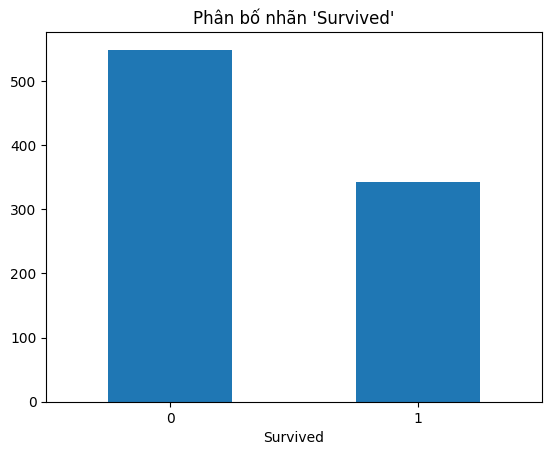

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.00,891.00,891.00,714.00,891.00,891.00,891.00
mean,446.00,0.38,2.31,29.70,0.52,0.38,32.20
std,257.35,0.49,0.84,14.53,1.10,0.81,49.69
min,1.00,0.00,1.00,0.42,0.00,0.00,0.00
25%,223.50,0.00,2.00,20.12,0.00,0.00,7.91
50%,446.00,0.00,3.00,28.00,0.00,0.00,14.45
75%,668.50,1.00,3.00,38.00,1.00,0.00,31.00
max,891.00,1.00,3.00,80.00,8.00,6.00,512.33


In [19]:
titanic = pd.read_csv("data/train.csv")
kham_pha(titanic, "Survived")

Lớp: ['0', '1'] | Train: 712 | Test: 179
Đặc trưng số (5): ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare']
Đặc trưng phân loại (2): ['Sex', 'Embarked']

==================== Decision Tree ====================
Tham số tốt nhất: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 10}
              precision    recall  f1-score   support

           0       0.77      0.87      0.82       110
           1       0.75      0.59      0.66        69

    accuracy                           0.77       179
   macro avg       0.76      0.73      0.74       179
weighted avg       0.76      0.77      0.76       179



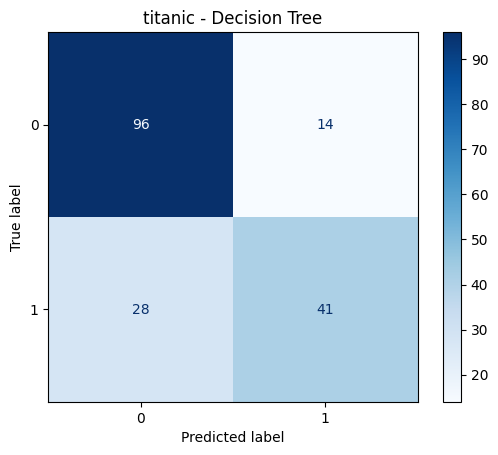


==================== Random Forest ====================
Tham số tốt nhất: {'max_depth': None, 'min_samples_leaf': 5, 'n_estimators': 50}
              precision    recall  f1-score   support

           0       0.79      0.92      0.85       110
           1       0.82      0.61      0.70        69

    accuracy                           0.80       179
   macro avg       0.81      0.76      0.77       179
weighted avg       0.80      0.80      0.79       179



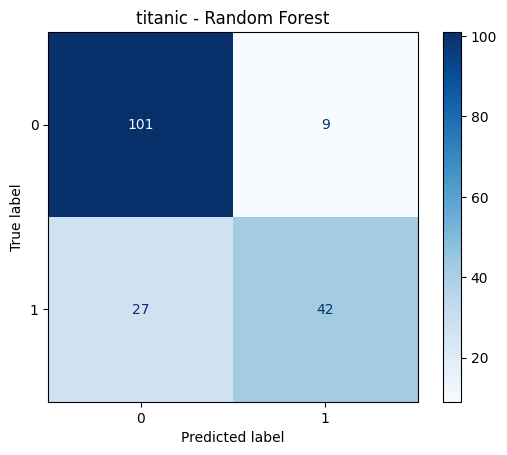


================ BẢNG SO SÁNH ================


,Mô hình,CV score,Train acc,Test acc,Precision,Recall,F1,ROC AUC
0,Decision Tree,0.8536,0.8624,0.7654,0.7455,0.5942,0.6613,0.7918
1,Random Forest,0.8762,0.8764,0.7989,0.8235,0.6087,0.7000,0.8341


Train acc >> Test acc nghĩa là mô hình có dấu hiệu quá khớp (overfitting).


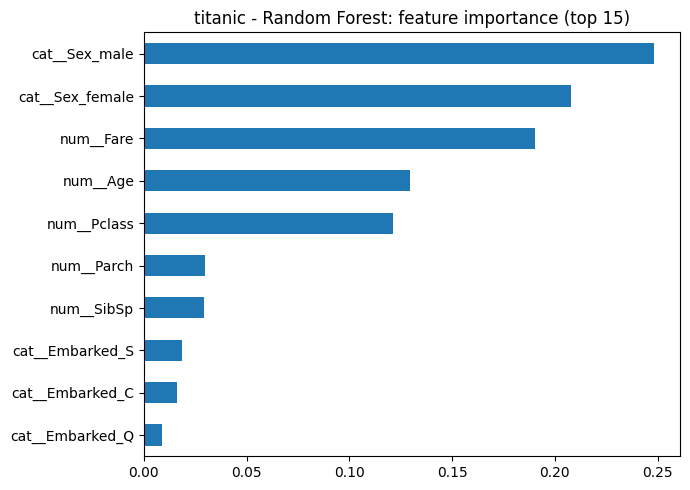

,Importance
cat__Sex_male,0.2485
cat__Sex_female,0.2080
num__Fare,0.1903
num__Age,0.1296
num__Pclass,0.1210
num__Parch,0.0300
num__SibSp,0.0293
cat__Embarked_S,0.0186


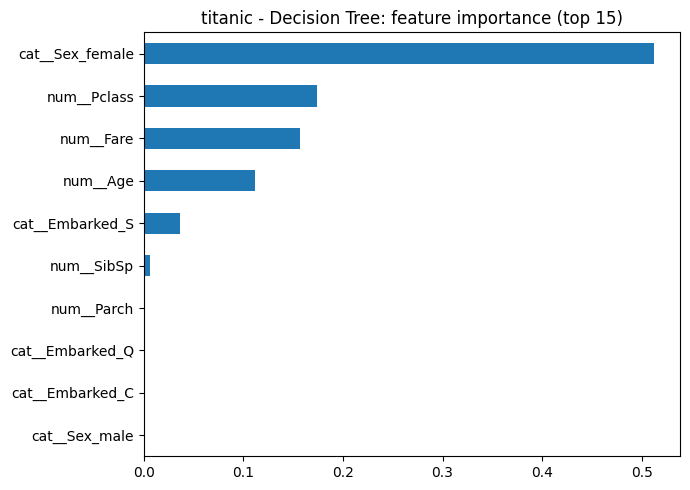

,Importance
cat__Sex_female,0.5129
num__Pclass,0.1744
num__Fare,0.1570
num__Age,0.1118
cat__Embarked_S,0.0362
num__SibSp,0.0067
num__Parch,0.0011
cat__Sex_male,0.0000


In [20]:
res_titanic, models_titanic = chay_bai_tap(
    titanic, target="Survived", models=["dt", "rf"], ten_bai="titanic",
    drop=["PassengerId", "Name", "Ticket", "Cabin"])

---
# BÀI 2.1.4 & 2.2.3 – BỆNH TIỂU ĐƯỜNG (Decision Tree, Random Forest, SVM)

Dữ liệu: https://www.kaggle.com/code/tumpanjawat/diabetes-eda-random-forest-hp → file `diabetes.csv` (Pima Indians).
Nhãn: `Outcome` (1 = mắc bệnh). Các cột `Glucose, BloodPressure, SkinThickness, Insulin, BMI` có giá trị 0 là **không hợp lý về y học**
→ coi là thiếu và điền bằng trung vị.

Kích thước: (768, 9)


,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1



Kiểu dữ liệu & giá trị thiếu:


,dtype,thiếu,số giá trị khác nhau
Pregnancies,int64,0,17
Glucose,int64,0,136
BloodPressure,int64,0,47
SkinThickness,int64,0,51
Insulin,int64,0,186
BMI,float64,0,248
DiabetesPedigreeFunction,float64,0,517
Age,int64,0,52
Outcome,int64,0,2



Phân bố nhãn:


Outcome
0    500
1    268
Name: count, dtype: int64

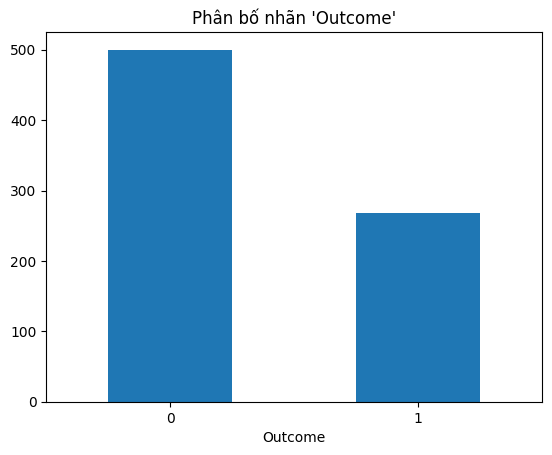

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00,768.00
mean,3.85,120.89,69.11,20.54,79.80,31.99,0.47,33.24,0.35
std,3.37,31.97,19.36,15.95,115.24,7.88,0.33,11.76,0.48
min,0.00,0.00,0.00,0.00,0.00,0.00,0.08,21.00,0.00
25%,1.00,99.00,62.00,0.00,0.00,27.30,0.24,24.00,0.00
50%,3.00,117.00,72.00,23.00,30.50,32.00,0.37,29.00,0.00
75%,6.00,140.25,80.00,32.00,127.25,36.60,0.63,41.00,1.00
max,17.00,199.00,122.00,99.00,846.00,67.10,2.42,81.00,1.00


In [21]:
diabetes = pd.read_csv("data/diabetes.csv")
kham_pha(diabetes, "Outcome")

In [22]:
cols_zero = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]
print("Số giá trị 0 ở các cột trên:")
print((diabetes[cols_zero] == 0).sum())

Số giá trị 0 ở các cột trên:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


### 2.1.4 – Cây quyết định & Random Forest

Lớp: ['0', '1'] | Train: 614 | Test: 154
Đặc trưng số (8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Đặc trưng phân loại (0): []

==================== Decision Tree ====================
Tham số tốt nhất: {'criterion': 'entropy', 'max_depth': 3, 'min_samples_leaf': 10}
              precision    recall  f1-score   support

           0       0.70      0.92      0.80       100
           1       0.65      0.28      0.39        54

    accuracy                           0.69       154
   macro avg       0.68      0.60      0.59       154
weighted avg       0.68      0.69      0.65       154



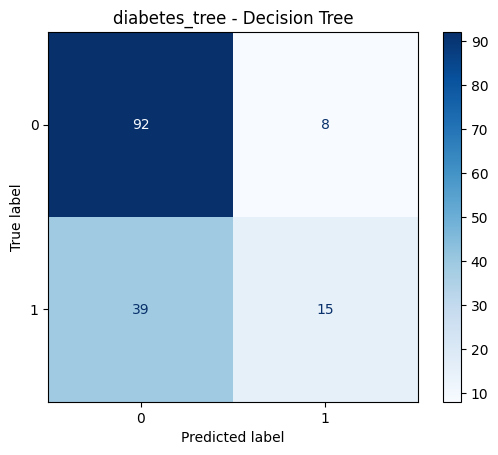


==================== Random Forest ====================
Tham số tốt nhất: {'max_depth': 5, 'min_samples_leaf': 5, 'n_estimators': 100}
              precision    recall  f1-score   support

           0       0.76      0.85      0.80       100
           1       0.64      0.50      0.56        54

    accuracy                           0.73       154
   macro avg       0.70      0.68      0.68       154
weighted avg       0.72      0.73      0.72       154



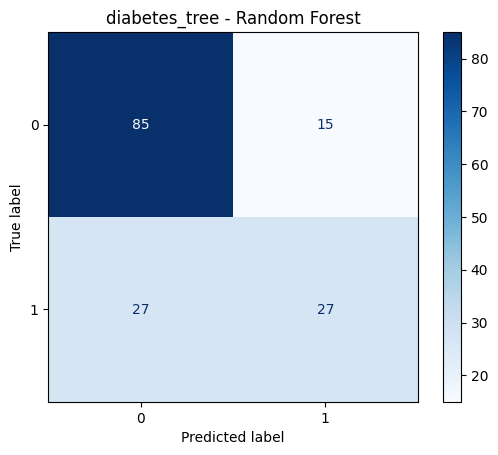


================ BẢNG SO SÁNH ================


,Mô hình,CV score,Train acc,Test acc,Precision,Recall,F1,ROC AUC
0,Decision Tree,0.8027,0.7606,0.6948,0.6522,0.2778,0.3896,0.7705
1,Random Forest,0.8409,0.8420,0.7273,0.6429,0.5000,0.5625,0.8120


Train acc >> Test acc nghĩa là mô hình có dấu hiệu quá khớp (overfitting).


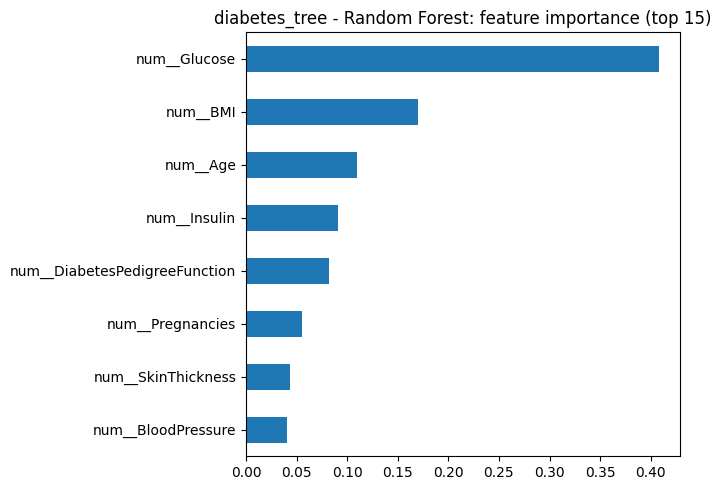

,Importance
num__Glucose,0.4085
num__BMI,0.1702
num__Age,0.1094
num__Insulin,0.0910
num__DiabetesPedigreeFunction,0.0819
num__Pregnancies,0.0556
num__SkinThickness,0.0432
num__BloodPressure,0.0402


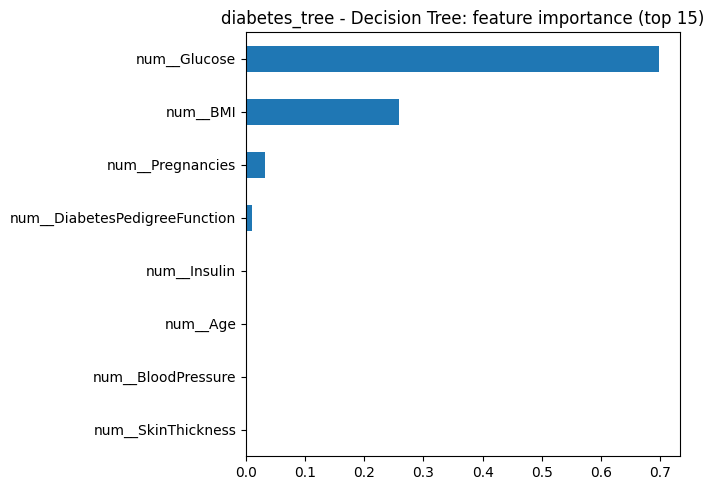

,Importance
num__Glucose,0.6987
num__BMI,0.2586
num__Pregnancies,0.0323
num__DiabetesPedigreeFunction,0.0104
num__Insulin,0.0000
num__Age,0.0000
num__BloodPressure,0.0000
num__SkinThickness,0.0000


In [23]:
res_dia_tree, models_dia_tree = chay_bai_tap(
    diabetes, target="Outcome", models=["dt", "rf"], ten_bai="diabetes_tree",
    zero_as_nan=cols_zero)

### 2.2.3 – SVM

Lớp: ['0', '1'] | Train: 614 | Test: 154
Đặc trưng số (8): ['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age']
Đặc trưng phân loại (0): []

==================== SVM ====================
Tham số tốt nhất: {'C': 1, 'gamma': 0.01, 'kernel': 'rbf'}
              precision    recall  f1-score   support

           0       0.74      0.84      0.79       100
           1       0.61      0.46      0.53        54

    accuracy                           0.71       154
   macro avg       0.68      0.65      0.66       154
weighted avg       0.70      0.71      0.70       154



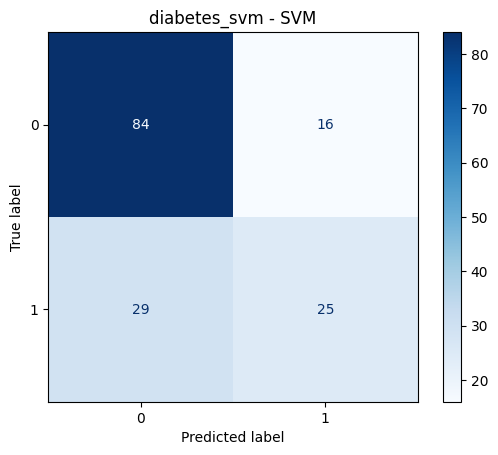


================ BẢNG SO SÁNH ================


,Mô hình,CV score,Train acc,Test acc,Precision,Recall,F1,ROC AUC
0,SVM,0.8432,0.785,0.7078,0.6098,0.463,0.5263,0.8052


Train acc >> Test acc nghĩa là mô hình có dấu hiệu quá khớp (overfitting).


In [24]:
res_dia_svm, models_dia_svm = chay_bai_tap(
    diabetes, target="Outcome", models=["svm"], ten_bai="diabetes_svm",
    zero_as_nan=cols_zero)

---
# BÀI 2.2.4 – ANIMAL CONDITION (SVM)

Dữ liệu: https://www.kaggle.com/code/kareemellithy/animal-condition-predict-svm-knn


['AnimalName', 'symptoms1', 'symptoms2', 'symptoms3', 'symptoms4', 'symptoms5', 'Dangerous']
Kích thước: (871, 7)


,AnimalName,symptoms1,symptoms2,symptoms3,symptoms4,symptoms5,Dangerous
0,Dog,Fever,Diarrhea,Vomiting,Weight loss,Dehydration,Yes
1,Dog,Fever,Diarrhea,Coughing,Tiredness,Pains,Yes
2,Dog,Fever,Diarrhea,Coughing,Vomiting,Anorexia,Yes
3,Dog,Fever,Difficulty breathing,Coughing,Lethargy,Sneezing,Yes
4,Dog,Fever,Diarrhea,Coughing,Lethargy,Blue Eye,Yes



Kiểu dữ liệu & giá trị thiếu:


,dtype,thiếu,số giá trị khác nhau
AnimalName,str,0,46
symptoms1,str,0,232
symptoms2,str,0,230
symptoms3,str,0,229
symptoms4,str,0,217
symptoms5,str,0,203
Dangerous,str,2,2



Phân bố nhãn:


Dangerous
Yes    849
No      20
Name: count, dtype: int64

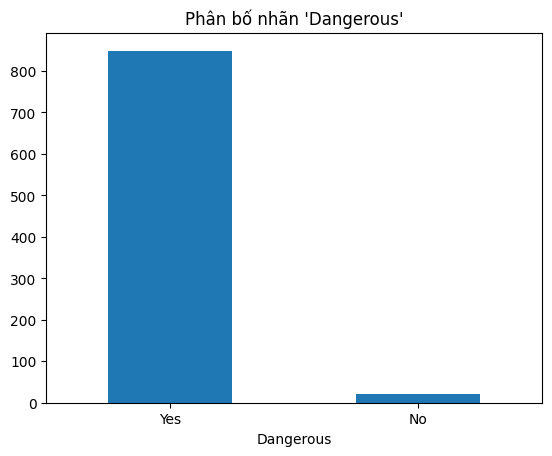

In [25]:
ANIMAL_FILE = "data/animal.csv"   
ANIMAL_TARGET = "Dangerous"           
ANIMAL_DROP = ["AnimalName"]          

animal = pd.read_csv(ANIMAL_FILE)
print(list(animal.columns))
kham_pha(animal, ANIMAL_TARGET)

Lớp: ['No', 'Yes'] | Train: 695 | Test: 174
Đặc trưng số (0): []
Đặc trưng phân loại (5): ['symptoms1', 'symptoms2', 'symptoms3', 'symptoms4', 'symptoms5']

==================== SVM ====================
Tham số tốt nhất: {'C': 10, 'gamma': 'scale', 'kernel': 'poly'}
              precision    recall  f1-score   support

          No       1.00      1.00      1.00         4
         Yes       1.00      1.00      1.00       170

    accuracy                           1.00       174
   macro avg       1.00      1.00      1.00       174
weighted avg       1.00      1.00      1.00       174



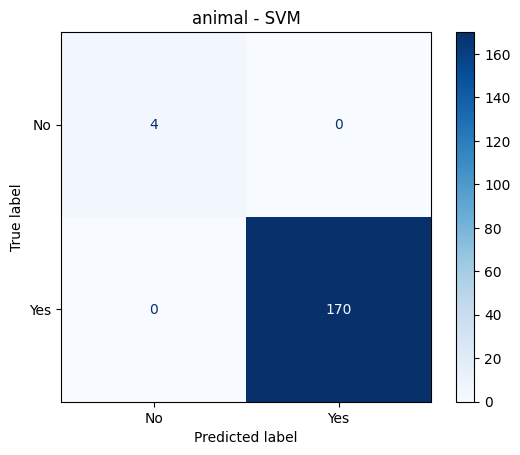


================ BẢNG SO SÁNH ================


,Mô hình,CV score,Train acc,Test acc,Precision,Recall,F1,ROC AUC
0,SVM,0.9287,1.0,1.0,1.0,1.0,1.0,1.0


Train acc >> Test acc nghĩa là mô hình có dấu hiệu quá khớp (overfitting).


In [26]:
res_animal, models_animal = chay_bai_tap(
    animal, target=ANIMAL_TARGET, models=["svm"], ten_bai="animal",
    drop=ANIMAL_DROP)

---
# BÀI 2.3.3 – HÀNH VI KHÁCH HÀNG (Naive Bayes)

Dữ liệu: https://www.kaggle.com/code/arezalo/customer-behaviour-prediction-naive-bayes → file `Customer_Behaviour.csv`
(`User ID`, `Gender`, `Age`, `EstimatedSalary`, `Purchased`). Nhãn: `Purchased`.
Có cả đặc trưng số lẫn phân loại (sau One-Hot) nên dùng **GaussianNB**.

Kích thước: (400, 5)


,User ID,Gender,Age,EstimatedSalary,Purchased
0,15624510,Male,19,19000,0
1,15810944,Male,35,20000,0
2,15668575,Female,26,43000,0
3,15603246,Female,27,57000,0
4,15804002,Male,19,76000,0



Kiểu dữ liệu & giá trị thiếu:


,dtype,thiếu,số giá trị khác nhau
User ID,int64,0,400
Gender,str,0,2
Age,int64,0,43
EstimatedSalary,int64,0,117
Purchased,int64,0,2



Phân bố nhãn:


Purchased
0    257
1    143
Name: count, dtype: int64

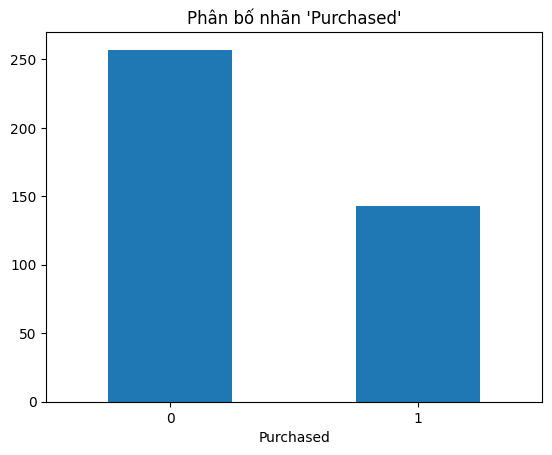

,User ID,Age,EstimatedSalary,Purchased
count,400.00,400.00,400.00,400.00
mean,15691539.76,37.66,69742.50,0.36
std,71658.32,10.48,34096.96,0.48
min,15566689.00,18.00,15000.00,0.00
25%,15626763.75,29.75,43000.00,0.00
50%,15694341.50,37.00,70000.00,0.00
75%,15750363.00,46.00,88000.00,1.00
max,15815236.00,60.00,150000.00,1.00


In [27]:
customer = pd.read_csv("data/Customer_Behaviour.csv")
kham_pha(customer, "Purchased")

Lớp: ['0', '1'] | Train: 320 | Test: 80
Đặc trưng số (2): ['Age', 'EstimatedSalary']
Đặc trưng phân loại (1): ['Gender']

==================== Naive Bayes ====================
Tham số tốt nhất: {'var_smoothing': 1e-09}
              precision    recall  f1-score   support

           0       0.90      0.92      0.91        51
           1       0.86      0.83      0.84        29

    accuracy                           0.89        80
   macro avg       0.88      0.87      0.88        80
weighted avg       0.89      0.89      0.89        80



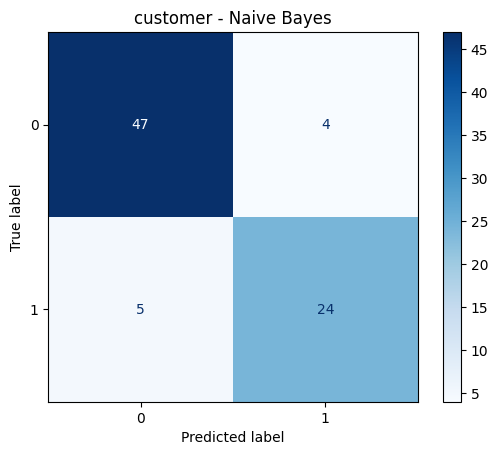


================ BẢNG SO SÁNH ================


,Mô hình,CV score,Train acc,Test acc,Precision,Recall,F1,ROC AUC
0,Naive Bayes,0.9482,0.8906,0.8875,0.8571,0.8276,0.8421,0.9473


Train acc >> Test acc nghĩa là mô hình có dấu hiệu quá khớp (overfitting).


In [28]:
res_customer, models_customer = chay_bai_tap(
    customer, target="Purchased", models=["nb"], ten_bai="customer",
    drop=["User ID"])

---
# BÀI 2.3.4 – MUSHROOM (Naive Bayes)

Dữ liệu: https://www.kaggle.com/datasets/uciml/mushroom-classification/data → file `mushrooms.csv`.
Nhãn: `class` (`e` = ăn được, `p` = độc). **Toàn bộ đặc trưng là phân loại** → mã hóa One-Hot và dùng **BernoulliNB**.

Kích thước: (8124, 23)


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g



Kiểu dữ liệu & giá trị thiếu:


,dtype,thiếu,số giá trị khác nhau
class,str,0,2
cap-shape,str,0,6
cap-surface,str,0,4
cap-color,str,0,10
bruises,str,0,2
odor,str,0,9
gill-attachment,str,0,2
gill-spacing,str,0,2
gill-size,str,0,2
gill-color,str,0,12



Phân bố nhãn:


class
e    4208
p    3916
Name: count, dtype: int64

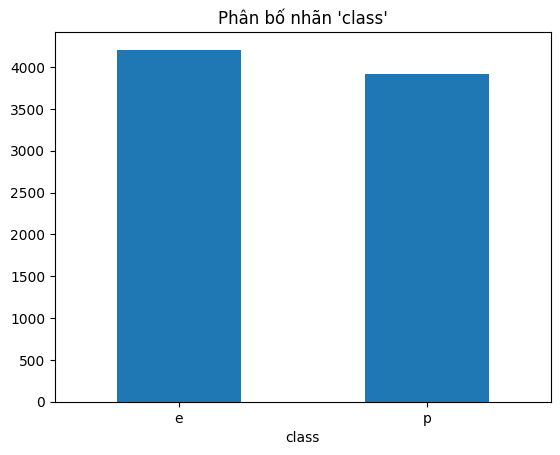

In [29]:
mushroom = pd.read_csv("data/mushrooms.csv")
kham_pha(mushroom, "class")

Lớp: ['e', 'p'] | Train: 6499 | Test: 1625
Đặc trưng số (0): []
Đặc trưng phân loại (22): ['cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor', 'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color', 'stalk-shape', 'stalk-root', 'stalk-surface-above-ring', 'stalk-surface-below-ring', 'stalk-color-above-ring', 'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number', 'ring-type', 'spore-print-color', 'population', 'habitat']

==================== Naive Bayes ====================
Tham số tốt nhất: {'alpha': 0.1}
              precision    recall  f1-score   support

           e       0.93      0.99      0.96       842
           p       0.99      0.92      0.96       783

    accuracy                           0.96      1625
   macro avg       0.96      0.96      0.96      1625
weighted avg       0.96      0.96      0.96      1625



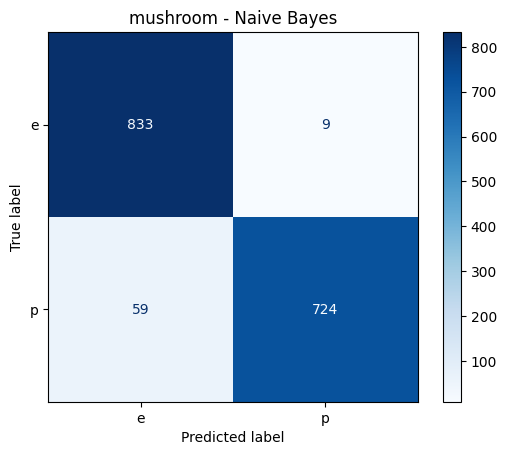


================ BẢNG SO SÁNH ================


,Mô hình,CV score,Train acc,Test acc,Precision,Recall,F1,ROC AUC
0,Naive Bayes,0.9978,0.9583,0.9582,0.9877,0.9246,0.9551,0.9976


Train acc >> Test acc nghĩa là mô hình có dấu hiệu quá khớp (overfitting).


In [30]:
res_mushroom, models_mushroom = chay_bai_tap(
    mushroom, target="class", models=["nb"], ten_bai="mushroom")